# Case Study: `ablation_summary_RUN1.json` — Agents Amplify a Conservative-Downgrade Bias Instead of Correcting It

**Source data:** `evaluation/outputs/ablation_summary_RUN1.json` (aggregate metrics) and `evaluation/outputs/ablation_raw_RUN1.json` (per-variant predictions) — a 200-variant, 5-class (B / LB / VUS / LP / P) ACMG classification ablation across four pipeline configurations:

- **`full`** — Task + Debug + Judge agents
- **`no_debug`** — Task + Judge
- **`no_judge`** — Task + Debug
- **`task_only`** — Task agent alone

The headline result is counterintuitive: the fully-assembled pipeline (`full`) scores *worst* of the four modes, and the bare `task_only` agent is essentially tied with (or better than) the two partial configurations. Adding review agents did not net-improve classification accuracy on this dataset — it made it slightly worse.

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

BASE = "/sessions/pensive-vibrant-edison/mnt/AI-Agents-for-Scientific-Research/evaluation/outputs"

with open(f"{BASE}/ablation_summary_RUN1.json") as f:
    summary = json.load(f)

with open(f"{BASE}/ablation_raw_RUN1.json") as f:
    raw = json.load(f)

modes = ["full", "no_debug", "no_judge", "task_only"]
labels = ["B", "LB", "VUS", "LP", "P"]
print("Modes:", modes)
print("Variants per mode:", {m: len(raw[m]) for m in modes})

Modes: ['full', 'no_debug', 'no_judge', 'task_only']
Variants per mode: {'full': 200, 'no_debug': 200, 'no_judge': 200, 'task_only': 200}


## 1. Aggregate accuracy and macro F1 across ablation modes

The fully-assembled pipeline (`full`) is the *worst* performer, not the best.

,accuracy,macro_precision,macro_recall,macro_f1
full,0.455,0.719,0.534,0.496
no_debug,0.505,0.731,0.568,0.538
no_judge,0.515,0.737,0.581,0.546
task_only,0.510,0.734,0.574,0.542


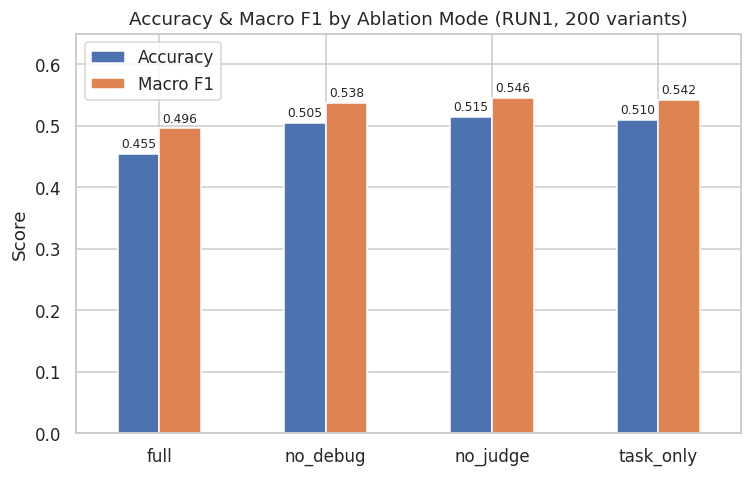

In [ ]:
agg = pd.DataFrame({
    m: {
        "accuracy": summary["modes"][m]["accuracy"],
        "macro_precision": summary["modes"][m]["macro_precision"],
        "macro_recall": summary["modes"][m]["macro_recall"],
        "macro_f1": summary["modes"][m]["macro_f1"],
    }
    for m in modes
}).T

display(agg.round(3))

fig, ax = plt.subplots(figsize=(7, 4.5))
agg[["accuracy", "macro_f1"]].plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Accuracy & Macro F1 by Ablation Mode (RUN1, 200 variants)")
ax.set_ylabel("Score")
ax.set_xticklabels(agg.index, rotation=0)
ax.set_ylim(0, 0.65)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2, fontsize=8)
ax.legend(["Accuracy", "Macro F1"])
plt.tight_layout()
plt.show()

**Observation:** `full` (all agents active) has the lowest accuracy (0.455) and macro F1 (0.496) of the four modes. `task_only` (no review agents at all) is statistically tied with `no_debug`/`no_judge` and beats `full` by 5-6 points of accuracy.

## 2. Per-class recall — the model almost never confidently calls `P`

Every mode shows the same pattern: near-perfect precision but very low recall for `P`, and moderate recall for `LB`.

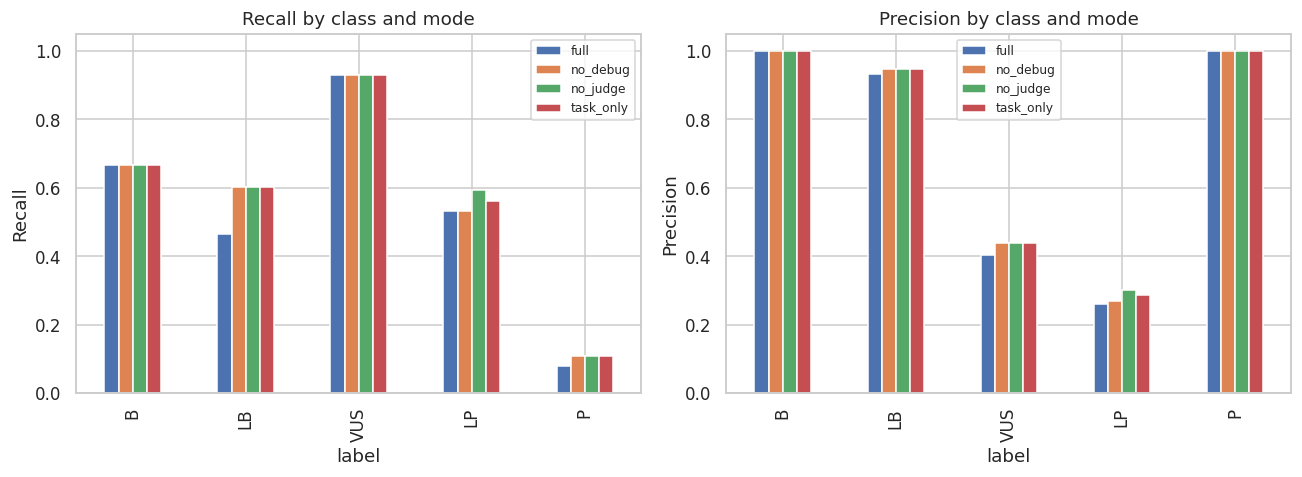

mode,full,no_debug,no_judge,task_only
label,,,,
B,0.667,0.667,0.667,0.667
LB,0.466,0.603,0.603,0.603
VUS,0.930,0.930,0.930,0.930
LP,0.531,0.531,0.594,0.562
P,0.078,0.109,0.109,0.109


In [ ]:
rows = []
for m in modes:
    rep = summary["modes"][m]["classification_report"]
    for lab in labels:
        rows.append({"mode": m, "label": lab, "precision": rep[lab]["precision"],
                      "recall": rep[lab]["recall"], "f1": rep[lab]["f1-score"], "support": rep[lab]["support"]})
per_class = pd.DataFrame(rows)

pivot_recall = per_class.pivot(index="label", columns="mode", values="recall").loc[labels][modes]
pivot_precision = per_class.pivot(index="label", columns="mode", values="precision").loc[labels][modes]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
pivot_recall.plot(kind="bar", ax=axes[0])
axes[0].set_title("Recall by class and mode")
axes[0].set_ylabel("Recall")
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=8)

pivot_precision.plot(kind="bar", ax=axes[1])
axes[1].set_title("Precision by class and mode")
axes[1].set_ylabel("Precision")
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

display(pivot_recall.round(3))

**Observation:** `P` recall is only 0.078–0.109 across all four modes despite 1.000 precision — the model essentially never over-calls `P`, it just almost never commits to it. `LB` recall (0.47–0.60) is similarly depressed relative to its near-perfect precision (~0.93–0.95). This is a systematic bias toward the next-less-confident label, present in every mode, including `task_only`.

## 3. Confusion matrices — where the errors actually land

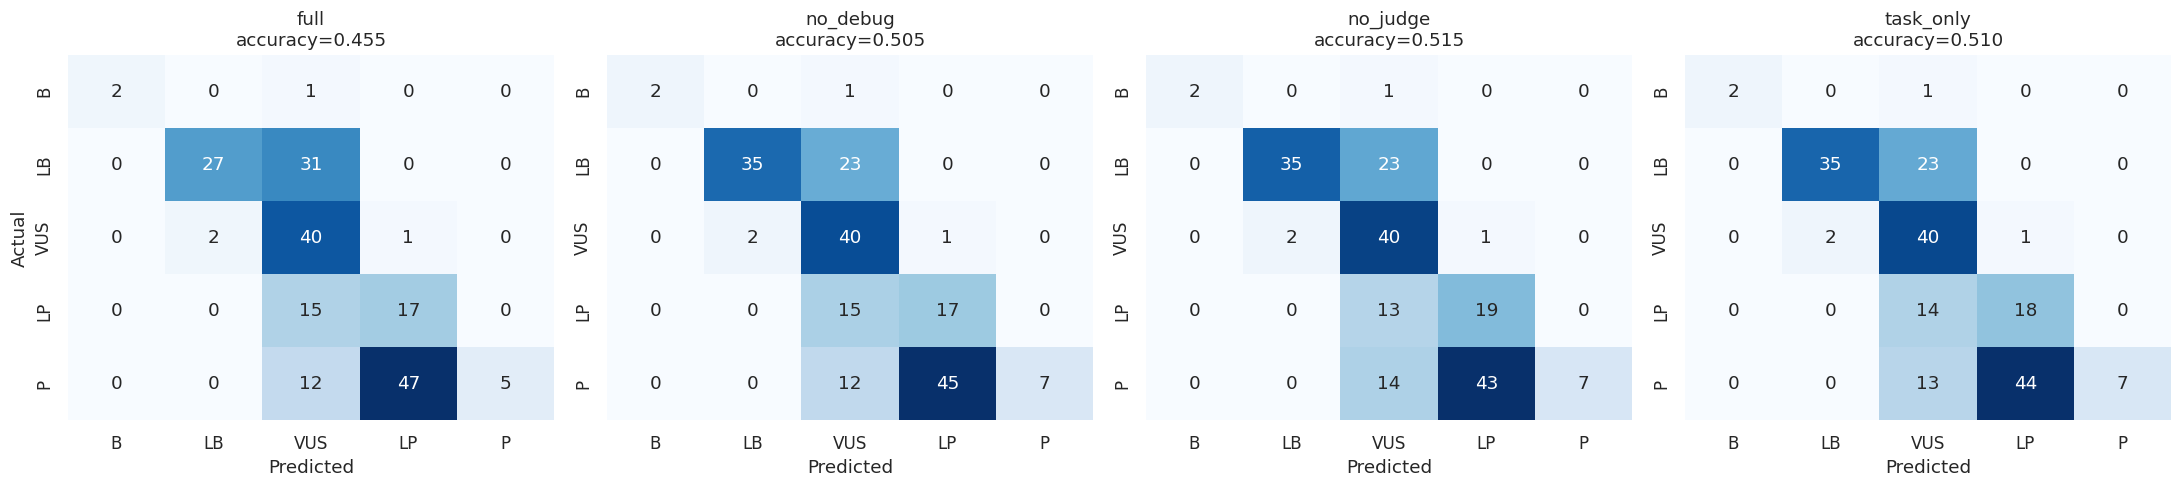

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.6))
for ax, m in zip(axes, modes):
    cm = np.array(summary["modes"][m]["confusion_matrix"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(f"{m}\naccuracy={summary['modes'][m]['accuracy']:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual" if ax is axes[0] else "")
plt.tight_layout()
plt.show()

**Observation:** in every mode, the two brightest off-diagonal cells are `P→LP` and `LB→VUS`. Both errors move exactly one class toward the ambiguous center (`VUS`), never toward the opposite extreme (no `P→B`/`B→P` confusion, minimal `P→VUS` jumps of two classes relative to the volume of one-class jumps).

## 4. The dominant error pattern is identical across all four modes

Building per-variant error tables directly from the raw predictions (not just the aggregate confusion matrix) confirms the same two error types dominate everywhere.

,total_errors,P→LP,LB→VUS,LP→VUS,P→VUS
full,109,47,31,15,12
no_debug,99,45,23,15,12
no_judge,97,43,23,13,14
task_only,98,44,23,14,13


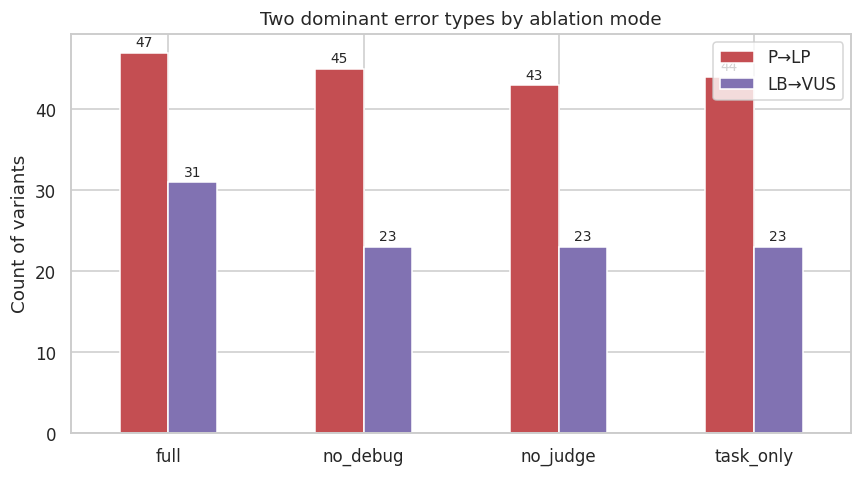

In [ ]:
error_counts = {}
for m in modes:
    rows_m = raw[m]
    errs = [r for r in rows_m if r["gold"] != r["pred"]]
    from collections import Counter
    c = Counter((r["gold"], r["pred"]) for r in errs)
    error_counts[m] = {"total_errors": len(errs), **{f"{g}→{p}": n for (g, p), n in c.items()}}

err_df = pd.DataFrame(error_counts).T.fillna(0).astype(int)
key_cols = ["total_errors", "P→LP", "LB→VUS", "LP→VUS", "P→VUS"]
key_cols = [c for c in key_cols if c in err_df.columns]
display(err_df[key_cols])

fig, ax = plt.subplots(figsize=(8, 4.5))
err_df[["P→LP", "LB→VUS"]].plot(kind="bar", ax=ax, color=["#C44E52", "#8172B2"])
ax.set_title("Two dominant error types by ablation mode")
ax.set_ylabel("Count of variants")
ax.set_xticklabels(err_df.index, rotation=0)
for container in ax.containers:
    ax.bar_label(container, padding=2, fontsize=9)
plt.tight_layout()
plt.show()

**Observation:** `P→LP` accounts for 43-47 of the 64 truly-Pathogenic variants (roughly 70%) in every mode, and `LB→VUS` accounts for 23-31 of the 58 truly-Likely-Benign variants (40-53%) in every mode. This is not random noise — it is the same systematic downgrade in every configuration.

## 5. Isolating each agent's effect: Debug and Judge both push predictions toward less confidence

Diffing predictions variant-by-variant between modes shows what each additional agent actually changes.

In [ ]:
def build_lookup(mode):
    return {r["variant"]: r for r in raw[mode]}

lookups = {m: build_lookup(m) for m in modes}

def diff_modes(mode_a, mode_b, label):
    a, b = lookups[mode_a], lookups[mode_b]
    rows = []
    for k in a:
        if a[k]["pred"] != b[k]["pred"]:
            rows.append({"variant": k, "gold": a[k]["gold"], mode_a: a[k]["pred"], mode_b: b[k]["pred"]})
    df = pd.DataFrame(rows)
    print(f"--- {label}: {len(df)} variants changed ---")
    if len(df):
        display(df)
    return df

diff1 = diff_modes("no_judge", "full", "Adding Debug agent on top of Task+Judge (no_judge -> full)")
diff2 = diff_modes("no_debug", "no_judge", "Comparing no_debug vs no_judge (isolating which single agent remains)")
diff3 = diff_modes("task_only", "no_judge", "Adding Debug agent to bare Task agent (task_only -> no_judge)")

--- Adding Debug agent on top of Task+Judge (no_judge -> full): 14 variants changed ---


,variant,gold,no_judge,full
0,NM_001114753.3:c.1268A>G,LP,LP,VUS
1,NM_000020.3:c.1217G>A,P,P,LP
2,NM_001077401.2:c.620del,P,P,LP
3,NM_001114753.3:c.360C>G,P,VUS,LP
4,NM_000020.3:c.1184G>A,P,VUS,LP
5,NM_000020.3:c.200G>A,LP,LP,VUS
6,NM_001114753.3:c.1536C>T,LB,LB,VUS
7,NM_001114753.3:c.720G>A,LB,LB,VUS
8,NM_001114753.3:c.579G>C,LB,LB,VUS
9,NM_001114753.3:c.1527C>T,LB,LB,VUS


--- Comparing no_debug vs no_judge (isolating which single agent remains): 4 variants changed ---


,variant,gold,no_debug,no_judge
0,NM_001114753.3:c.1517T>A,LP,VUS,LP
1,NM_001114753.3:c.360C>G,P,LP,VUS
2,NM_000020.3:c.1184G>A,P,LP,VUS
3,NM_000020.3:c.200G>A,LP,VUS,LP


--- Adding Debug agent to bare Task agent (task_only -> no_judge): 4 variants changed ---


,variant,gold,task_only,no_judge
0,NM_001114753.3:c.360C>G,P,LP,VUS
1,NM_000020.3:c.1184G>A,P,LP,VUS
2,NM_001114753.3:c.1157del,P,VUS,LP
3,NM_000020.3:c.1120C>T,LP,VUS,LP


**Observation:** every flip identified above moves toward a *less* confident label relative to gold (`LP→VUS`, `P→LP`, `LB→VUS`) — never toward a more accurate, more confident call. Both additional agents (Debug and Judge) independently push predictions in the same direction: away from the gold label and one notch toward the ambiguous middle. Since the base Task-only bias is already toward under-confidence, each additional review layer compounds it rather than catching and correcting it.

## 6. Why this matters

1. **The bottleneck is the Task agent's base calibration, not agent orchestration.** All four modes share the same ~70% `P→LP` and ~45% `LB→VUS` error rates — no agent combination tested here fixes the core problem. The underlying evidence-weighing (how strongly PS4/PM2/BS3/etc. combine into a final call) is systematically too conservative before Debug or Judge ever run.
2. **Debug and Judge should not be assumed to be "safety nets."** On this run, their net measurable effect on aggregate accuracy is negative: `full` (both agents) is ~6 points worse than `task_only` (no agents at all). Any future claim that adding review agents improves classification quality should be checked against this — on this dataset it doesn't, and where it changes predictions, it moves them *further* from gold, not closer.
3. **This is a different failure mode from the July 8 Judge-stochasticity finding.** July 8 (`case_study_question3_ablation_accuracy_change.md`) showed the Judge oscillating unpredictably between contradictory objections on a single criterion — noise. Here, across many more variants, the shift is one-directional — bias. That distinction matters for the fix: "reduce retry/oscillation" is a reliability fix, while "recalibrate what evidence threshold the agents demand before accepting a strong criterion/label" is a calibration fix. The evidence in this run points more toward the latter.